In [1]:
# ============================================================
# Project 2: The Staffing Time Bomb
# Analyst: Adebowale Adebare
# Source: NHS Digital Workforce Statistics (May 2026)
# Date: August 2026
# ============================================================

# Import all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings 
warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.2f}'.format
print("All Libraries imported successfully!")

All Libraries imported successfully!


In [2]:
# NHS workforce headcount by region — 17 years of data (2009-2026)

df_core15 = pd.read_csv(r"C:\Portfolio\Project2_NHS_Workforce\data\Core 15. Staff group - GOR, May-26.csv")
df_core15.head()

,DATA_MONTH,DATA_LEVEL,GOR_CODE,GOR_NAME,MAIN_STAFF_GROUP,STAFF_GROUP_1,FTE,HEADCOUNT
0,2009-09-30,Government Office Region,A,North East,All staff groups,All staff groups,61480.83,70300
1,2009-09-30,Government Office Region,A,North East,Professionally qualified clinical staff,All staff groups,31641.03,35276
2,2009-09-30,Government Office Region,A,North East,Professionally qualified clinical staff,Ambulance staff,711.77,732
3,2009-09-30,Government Office Region,A,North East,Professionally qualified clinical staff,HCHS doctors - All grades,5254.84,5621
4,2009-09-30,Government Office Region,A,North East,Professionally qualified clinical staff,HCHS doctors - Associate Specialist,161.13,178


In [3]:
# Annual NHS staff leavers and joiners by region (2009-2026)

df_turnover = pd.read_csv(r"C:\Portfolio\Project2_NHS_Workforce\data\Turnover 1. Staff group - NHSE region, annual, Sep-09 to May-26.csv")
df_turnover.head()

,PERIOD,TYPE,NHSE_REGION_CODE,NHSE_REGION_NAME,MAIN_STAFF_GROUP,STAFF_GROUP,HC,FTE
0,200909 to 201009,Denominator at end of period,All NHSE regions,All NHSE regions,All staff groups,All staff groups,1159716,1008013.26
1,200909 to 201009,Denominator at end of period,All NHSE regions,All NHSE regions,Professionally qualified clinical staff,All staff groups,600547,533577.05
2,200909 to 201009,Denominator at end of period,All NHSE regions,All NHSE regions,Professionally qualified clinical staff,HCHS doctors - All grades,103238,96547.08
3,200909 to 201009,Denominator at end of period,All NHSE regions,All NHSE regions,Professionally qualified clinical staff,HCHS doctors - Consultant,38258,36269.58
4,200909 to 201009,Denominator at end of period,All NHSE regions,All NHSE regions,Professionally qualified clinical staff,HCHS doctors - Associate Specialist,3711,3254.90


In [4]:
# Convert date to datetime and extract year for easier grouping

df_core15['DATA_MONTH'] = pd.to_datetime(df_core15['DATA_MONTH'])
df_core15['Year'] = df_core15['DATA_MONTH'].dt.year
df_core15.head()

,DATA_MONTH,DATA_LEVEL,GOR_CODE,GOR_NAME,MAIN_STAFF_GROUP,STAFF_GROUP_1,FTE,HEADCOUNT,Year
0,2009-09-30,Government Office Region,A,North East,All staff groups,All staff groups,61480.83,70300,2009
1,2009-09-30,Government Office Region,A,North East,Professionally qualified clinical staff,All staff groups,31641.03,35276,2009
2,2009-09-30,Government Office Region,A,North East,Professionally qualified clinical staff,Ambulance staff,711.77,732,2009
3,2009-09-30,Government Office Region,A,North East,Professionally qualified clinical staff,HCHS doctors - All grades,5254.84,5621,2009
4,2009-09-30,Government Office Region,A,North East,Professionally qualified clinical staff,HCHS doctors - Associate Specialist,161.13,178,2009


In [5]:
# Convert period column and keep only relevant columns

df_turnover = df_turnover.drop(columns=['NHSE_REGION_CODE'])
df_turnover.head()

,PERIOD,TYPE,NHSE_REGION_NAME,MAIN_STAFF_GROUP,STAFF_GROUP,HC,FTE
0,200909 to 201009,Denominator at end of period,All NHSE regions,All staff groups,All staff groups,1159716,1008013.26
1,200909 to 201009,Denominator at end of period,All NHSE regions,Professionally qualified clinical staff,All staff groups,600547,533577.05
2,200909 to 201009,Denominator at end of period,All NHSE regions,Professionally qualified clinical staff,HCHS doctors - All grades,103238,96547.08
3,200909 to 201009,Denominator at end of period,All NHSE regions,Professionally qualified clinical staff,HCHS doctors - Consultant,38258,36269.58
4,200909 to 201009,Denominator at end of period,All NHSE regions,Professionally qualified clinical staff,HCHS doctors - Associate Specialist,3711,3254.90


In [6]:
# Q1: How many NHS staff are there currently per region? (May 2026)
# Filter to summary rows only — avoids double counting staff groups

q1 = df_core15[
    (df_core15['MAIN_STAFF_GROUP'] == 'All staff groups') &
    (df_core15['STAFF_GROUP_1'] == 'All staff groups') &
    (df_core15['Year'] == 2026)
].sort_values('HEADCOUNT', ascending=False)

q1[['GOR_NAME', 'HEADCOUNT', 'FTE']]

,GOR_NAME,HEADCOUNT,FTE
4293,London,259976,240840.72
4158,North West,236825,210734.89
4320,South East,211591,189084.01
4239,West Midlands,167459,147745.70
4185,Yorkshire and the Humber,157828,137437.47
4347,South West,151694,132322.69
4266,East of England,139457,124918.92
4212,East Midlands,126469,111277.25
4131,North East,86746,76696.38


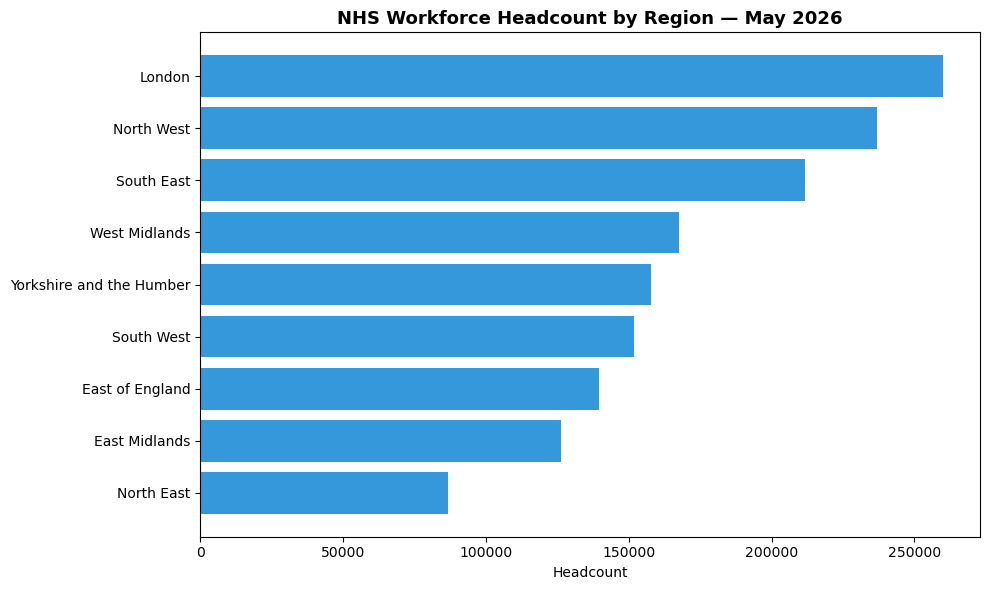

In [7]:
# Horizontal bar chart — NHS headcount by region (May 2026)
plt.figure(figsize=(10, 6))
plt.barh(q1['GOR_NAME'], q1['HEADCOUNT'], color='#3498db')
plt.title('NHS Workforce Headcount by Region — May 2026', 
          fontsize=13, fontweight='bold')
plt.xlabel('Headcount')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r"C:\Portfolio\Project2_NHS_Workforce\chart1_headcount_by_region.png", dpi=150)
plt.show()

In [8]:
# Q2: Has total NHS staffing grown or shrunk since 2009?
# Sum all regions per year to get national picture
q2 = df_core15[
    (df_core15['MAIN_STAFF_GROUP'] == 'All staff groups') &
    (df_core15['STAFF_GROUP_1'] == 'All staff groups')
].groupby('Year')['HEADCOUNT'].sum().reset_index()

q2

,Year,HEADCOUNT
0,2009,1155327
1,2010,1165318
2,2011,1142009
3,2012,1117633
4,2013,1111800
5,2014,1132216
6,2015,1151718
7,2016,1176233
8,2017,1193667
9,2018,1217286


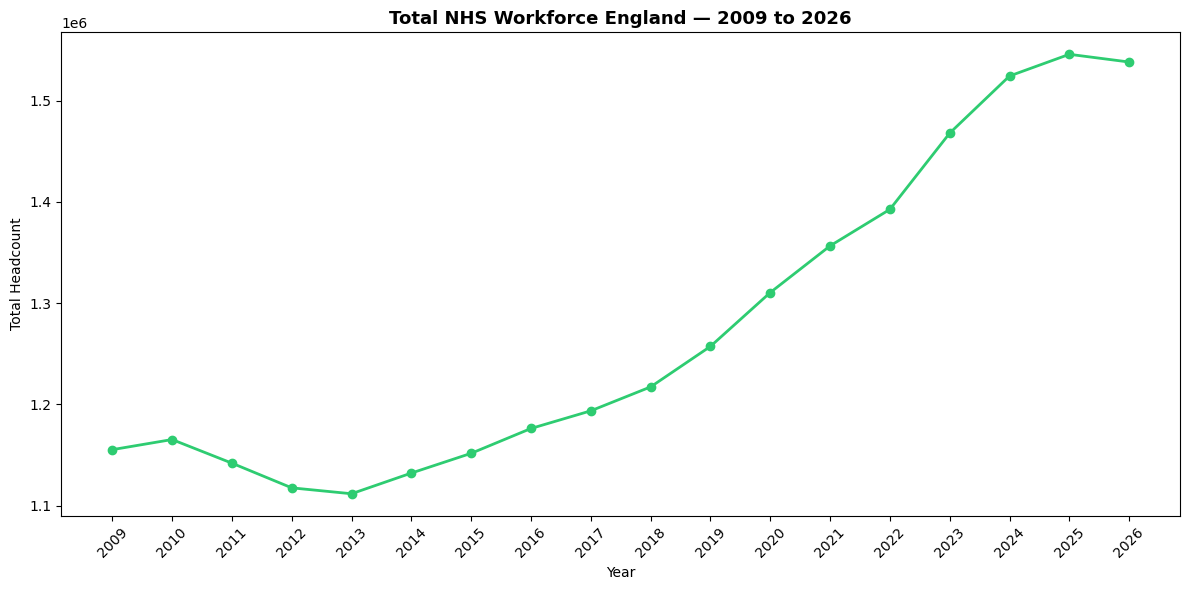

In [9]:
# Line chart — NHS workforce growth trend 2009-2026
plt.figure(figsize=(12, 6))
plt.plot(q2['Year'], q2['HEADCOUNT'], 
         marker='o', color='#2ecc71', linewidth=2)
plt.title('Total NHS Workforce England — 2009 to 2026',
          fontsize=13, fontweight='bold')
plt.ylabel('Total Headcount')
plt.xlabel('Year')
plt.xticks(q2['Year'], rotation=45)
plt.tight_layout()
plt.savefig(r"C:\Portfolio\Project2_NHS_Workforce\chart2_workforce_trend.png", dpi=150)
plt.show()

In [10]:
# Q3: Which staff groups are growing and which are shrinking?
# Compare headcount per staff group between 2009 and 2026

earliest = df_core15[
    (df_core15['Year'] == 2009) &
    (df_core15['STAFF_GROUP_1'] == 'All staff groups')
].groupby('MAIN_STAFF_GROUP')['HEADCOUNT'].sum()

latest = df_core15[
    (df_core15['Year'] == 2026) &
    (df_core15['STAFF_GROUP_1'] == 'All staff groups')
].groupby('MAIN_STAFF_GROUP')['HEADCOUNT'].sum()

q3 = pd.DataFrame({'2009': earliest, '2026': latest})
q3['Change'] = q3['2026'] - q3['2009']
q3['Change_%'] = (q3['Change'] / q3['2009'] * 100).round(1)
q3.sort_values('Change_%', ascending=False)

,2009,2026,Change,Change_%
MAIN_STAFF_GROUP,,,,
Professionally qualified clinical staff,596055,838649,242594,40.70
Support to clinical staff,341343,461713,120370,35.30
All staff groups,1155327,1538045,382718,33.10
NHS infrastructure support,215508,238998,23490,10.90


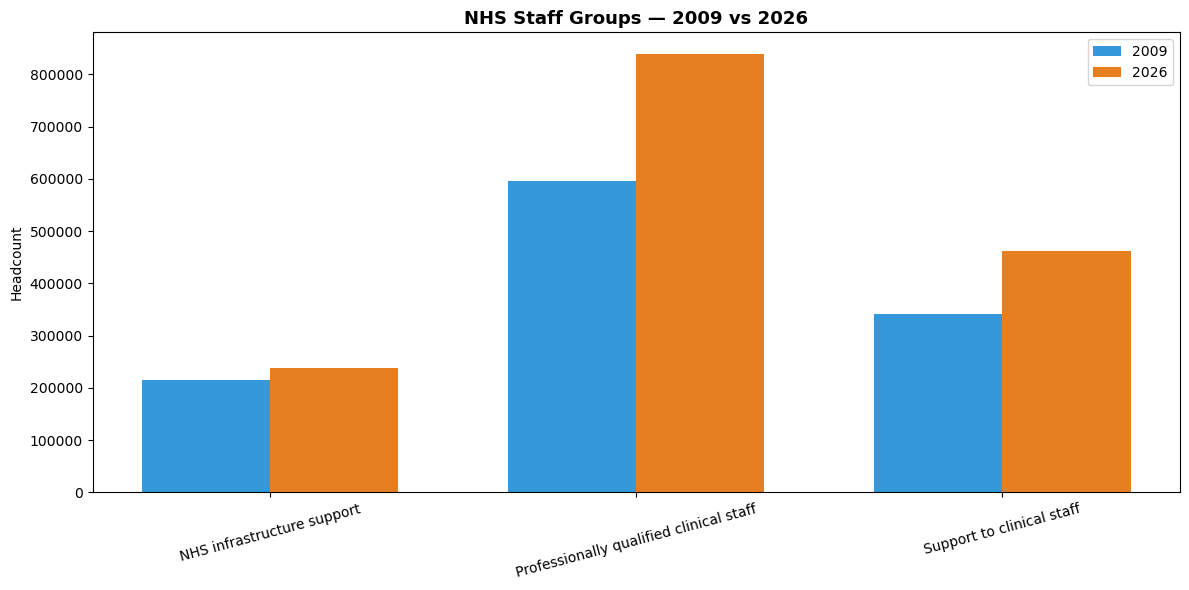

In [11]:
# Bar chart — staff group growth 2009 vs 2026
q3_filtered = q3.drop(index='All staff groups')

x = np.arange(len(q3_filtered.index))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, q3_filtered['2009'], width, label='2009', color='#3498db')
plt.bar(x + width/2, q3_filtered['2026'], width, label='2026', color='#e67e22')

plt.title('NHS Staff Groups — 2009 vs 2026', fontsize=13, fontweight='bold')
plt.ylabel('Headcount')
plt.xticks(x, q3_filtered.index, rotation=15)
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Portfolio\Project2_NHS_Workforce\chart3_staff_groups.png", dpi=150)
plt.show()

In [12]:
# Q4: What is the NHS staff turnover rate nationally over time?
# Filter to leavers, all staff groups, all regions combined
q4 = df_turnover[
    (df_turnover['TYPE'] == 'Leavers') &
    (df_turnover['MAIN_STAFF_GROUP'] == 'All staff groups') &
    (df_turnover['NHSE_REGION_NAME'] == 'All NHSE regions') &
    (df_turnover['STAFF_GROUP'] == 'All staff groups')
][['PERIOD', 'HC']]

q4

,PERIOD,HC
648,200909 to 201009,109330
1512,201009 to 201109,122964
2374,201109 to 201209,131433
3238,201209 to 201309,134084
4102,201309 to 201409,121632
4965,201409 to 201509,129642
5828,201509 to 201609,131210
6691,201609 to 201709,135703
7554,201709 to 201809,133626
8416,201809 to 201909,133029


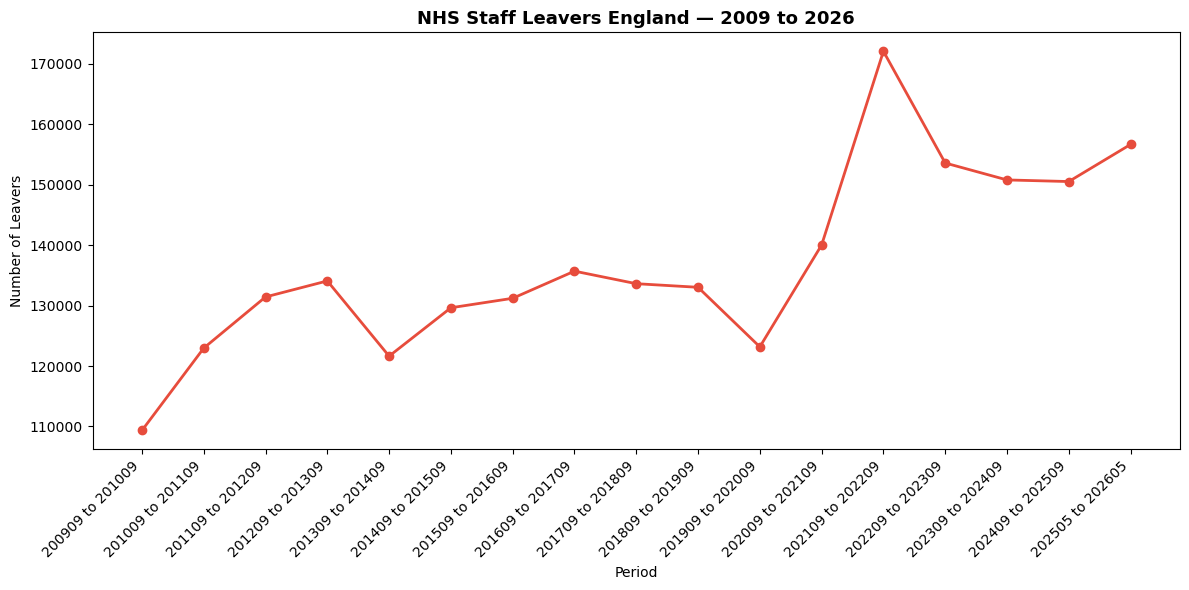

In [13]:
# Line chart — NHS staff leavers trend 2009-2026
plt.figure(figsize=(12, 6))
plt.plot(range(len(q4)), q4['HC'], 
         marker='o', color='#e74c3c', linewidth=2)
plt.title('NHS Staff Leavers England — 2009 to 2026',
          fontsize=13, fontweight='bold')
plt.ylabel('Number of Leavers')
plt.xlabel('Period')
plt.xticks(range(len(q4)), q4['PERIOD'], rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r"C:\Portfolio\Project2_NHS_Workforce\chart4_leavers_trend.png", dpi=150)
plt.show()

In [14]:
# Q5: Which regions have the highest staff turnover?
# Filter to most recent period and leavers only
q5 = df_turnover[
    (df_turnover['TYPE'] == 'Leavers') &
    (df_turnover['MAIN_STAFF_GROUP'] == 'All staff groups') &
    (df_turnover['STAFF_GROUP'] == 'All staff groups') &
    (df_turnover['PERIOD'] == '202505 to 202605') &
    (df_turnover['NHSE_REGION_NAME'] != 'All NHSE regions')
][['NHSE_REGION_NAME', 'HC']].sort_values('HC', ascending=False)

q5

,NHSE_REGION_NAME,HC
14549,Midlands,28935
14630,North East and Yorkshire,25602
14469,London,25546
14603,North West,23634
14522,South East,21527
14496,South West,16200
14576,East of England,15267


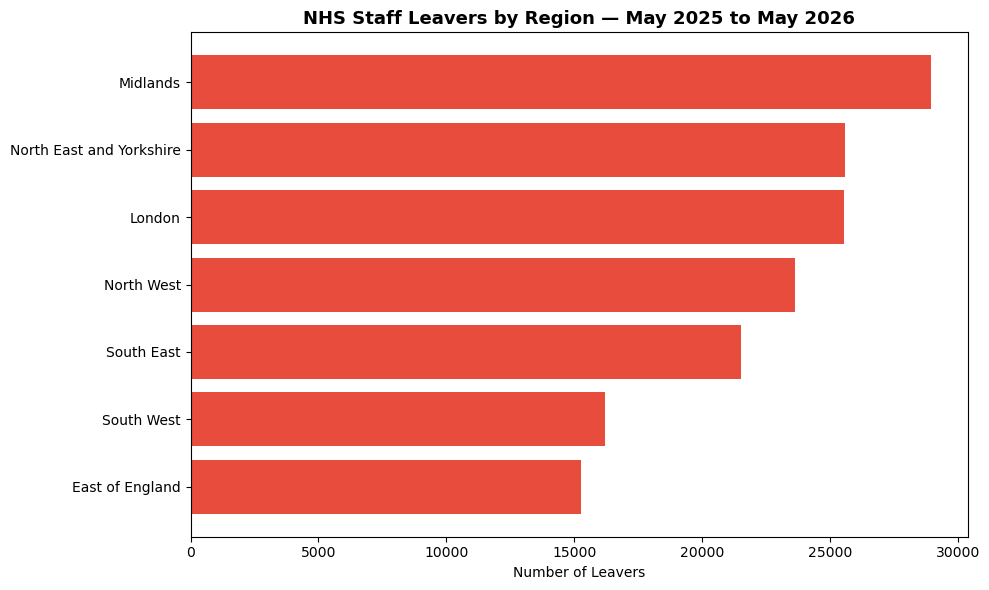

In [15]:
# Horizontal bar chart — leavers by region (most recent period)
plt.figure(figsize=(10, 6))
plt.barh(q5['NHSE_REGION_NAME'], q5['HC'], color='#e74c3c')
plt.title('NHS Staff Leavers by Region — May 2025 to May 2026',
          fontsize=13, fontweight='bold')
plt.xlabel('Number of Leavers')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r"C:\Portfolio\Project2_NHS_Workforce\chart5_leavers_by_region.png", dpi=150)
plt.show()

# Project 2 — The Staffing Time Bomb
## Analysing NHS Workforce Trends 2009-2026

### Overview
This project analyses 17 years of NHS workforce data using official NHS Digital 
statistics published May 2026. The analysis investigates whether the NHS is facing 
a staffing crisis — examining headcount trends, staff group changes and regional 
turnover patterns across England.

### Tools Used
- Python (Pandas) — Data loading, cleaning and analysis
- Matplotlib — Data visualisation

### Data Source
NHS Digital Workforce Statistics (May 2026)
digital.nhs.uk/data-and-information/publications/statistical/nhs-workforce-statistics

### Files Used
| File | Purpose |
|---|---|
| Core 15 — Staff group by GOR | Headcount by region (2009-2026) |
| Turnover 1 — Staff group by region | Annual leavers and joiners (2009-2026) |

### Key Findings

**1. NHS workforce grew by 33% since 2009 — but is now declining**
Total headcount grew from 1,155,327 in 2009 to a peak of 1,545,665 in 2025.
However 2026 shows the first decline in 12 years — dropping to 1,538,045.
This reversal is an early warning signal of workforce instability.

**2. Professionally qualified clinical staff saw the biggest growth**
Clinical staff grew by 40.7% since 2009 — from 596,055 to 838,649.
NHS infrastructure support grew by only 10.9% — admin and support being squeezed.

**3. Staff leavers have increased by 43% since 2009**
In 2009 — 109,330 NHS staff left. By 2021-22 this peaked at 172,094 — a 57% 
increase. Even now leavers remain 43% above 2009 baseline at 156,676 annually.

**4. The Midlands faces the biggest retention crisis**
With 28,935 leavers in the most recent period — the Midlands loses more staff 
than any other region. London and North East & Yorkshire follow closely behind.

**5. The time bomb is real — growth is reversing while leavers remain high**
The combination of slowing growth (Q2) and persistently high leavers (Q4) 
creates a dangerous gap — the NHS is losing staff faster than it can replace them.

### Business Relevance to GoldCare Connect
These findings validate GoldCare Connect's market opportunity:
- High staff turnover means care homes constantly need to fill shifts ✅
- Regions with highest NHS leavers overlap with care sector pressures ✅
- A platform reducing dependency on expensive agencies addresses this crisis directly ✅

### Files
- `Project2_NHS_Workforce_Analysis.ipynb` — Full analysis notebook
- Charts saved as PNG files

In [16]:
print(os.getcwd())

C:\Users\adeba
